## Notebook roadmap
This notebook reproduces **SM Figure 2** (migrated from old `figure_3_ablations.ipynb`).

Figure intent:
- evaluate clustering phase maps across network-width/depth/sample-size ablations,
- compare three divergences (`hellinger`, `triangular`, `jensen_shannon`),
- export one PDF per `(divergence, samples_per_point)` to `./sm_figures/`.


In [8]:
import os
import pickle

import numpy as np
import torch as pt

#%matplotlib widget
from matplotlib import pyplot as plt
from matplotlib import cm
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator, FuncFormatter
from scipy.interpolate import griddata

from nestconf import Configurable
from typing import Tuple
from sklearn.cluster import HDBSCAN

from utils.aggregation import aggregate_seeded_results


# Common settings
Set typography and shared plotting style for supplementary figure rendering.


In [9]:
AXES_LINEWIDTH = 1.0
TICK_SIZE = 8
LABEL_SIZE = 9

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'sans-serif',
    'text.latex.preamble': '\n'.join([
        r'\usepackage[semibold,sfdefault]{libertine}',
        r'\usepackage[libertine]{newtxmath}',
    ]),
    'axes.linewidth': AXES_LINEWIDTH,
})

class_to_colour = {
    -1: "black",          # mild grey  (noise / unassigned)
     0: "xkcd:periwinkle",  # blue
     1: "xkcd:peach",      # green
     2: "xkcd:bordeaux",       # bordeaux
     3: 'xkcd:light red',
     4: 'xkcd:purple',      # 
    5: 'xkcd:light blue',  # red
    6: 'xkcd:yellow',  # yellow
    7: 'xkcd:light purple',  # cyan
    8: 'xkcd:magenta',  # magenta
}
all_labels      = [-1, 0, 1, 2, 3, 4, 5]#, 6, 7, 8,]                
colour_list = [class_to_colour[label] for label in all_labels]
cluster_cmap = mcolors.ListedColormap(colour_list, name='cluster_cmap')
cluster_bounds = np.arange(len(all_labels) + 1) - 1.5
cluster_norm = mcolors.BoundaryNorm(cluster_bounds, cluster_cmap.N)


# Load and aggregate data
Load first-level artifacts from `../data/figures/sm_figure_2/hyperparameter_sweep` and aggregate seeded matrices.


In [10]:
class Experiment(Configurable):
    """Schema for pickled experiment-config keys in the hyperparameter sweep payload."""

    dim: int = None
    lattice_type: int = None
    system_size: int = None
    bases_to_include: Tuple = None
    samples_per_point: int = None
    network_width: int = None
    network_depth: int = None


data_dir = '../data/figures/sm_figure_2/hyperparameter_sweep'
with open(os.path.join(data_dir, 'seeded_f_matrices_dict.pickle'), 'rb') as handle:
    seeded_f_matrices_dict = pickle.load(handle)
with open(os.path.join(data_dir, 'seeded_f_matrices_std_dict.pickle'), 'rb') as handle:
    seeded_f_matrices_std_dict = pickle.load(handle)
with open(os.path.join(data_dir, 'coords_dict.pickle'), 'rb') as handle:
    coords_dict = pickle.load(handle)

f_matrices_dict = {}
f_matrices_std_dict = {}
for exp_config in seeded_f_matrices_dict:
    f_matrices_dict[exp_config] = {}
    f_matrices_std_dict[exp_config] = {}

    for divergence in seeded_f_matrices_dict[exp_config]:
        f_matrix, f_matrix_std, _, _ = aggregate_seeded_results(
            seeded_f_tensors=list(seeded_f_matrices_dict[exp_config][divergence].values()),
            seeded_std_tensors=list(seeded_f_matrices_std_dict[exp_config][divergence].values()),
            verbose=True,
            use_inverse_variance_weighting=False,
        )
        f_matrices_dict[exp_config][divergence] = f_matrix
        f_matrices_std_dict[exp_config][divergence] = f_matrix_std


Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results from 10 seeds.
Aggregating results 

## Ablation axes and label anchors
Define sorting anchors used to map HDBSCAN cluster IDs to stable semantic labels.


In [11]:
anchor2lambda = {
    'min_x_min_z': lambda tup: (tup[1][0], tup[1][1]),
    'min_x_max_z': lambda tup: (tup[1][0], -tup[1][1]),
    'max_x_min_z': lambda tup: (-tup[1][0], tup[1][1]),
}
anchor2label = {
    'min_x_min_z': 0,
    'min_x_max_z': 1,
    'max_x_min_z': 2,
}

unq_sample_sizes = []
unq_widths = []
unq_depths = []
for exp_config in f_matrices_dict:
    if exp_config.samples_per_point not in unq_sample_sizes:
        unq_sample_sizes.append(exp_config.samples_per_point)
    if exp_config.network_width not in unq_widths:
        unq_widths.append(exp_config.network_width)
    if exp_config.network_depth not in unq_depths:
        unq_depths.append(exp_config.network_depth)

# Requested: skip Ns=500 panels.
unq_sample_sizes = [ns for ns in unq_sample_sizes if ns != 500]

num_widths = len(unq_widths)
num_depths = len(unq_depths)

divergence2label = {
    'hellinger': 'Hellinger',
    'triangular': 'Le Cam',
    'jensen_shannon': 'Jensen-Shannon',
}
divergence2idx = {
    'hellinger': 0,
    'triangular': 1,
    'jensen_shannon': 2,
}


## Plot helper
Compact axis formatter for narrow panel grids.


In [12]:
def compact_axes(ax, *, x_tex=None, y_tex=None, bottom_only=False):
    """Show endpoint numeric ticks and symbolic center labels on both axes."""

    xmin, xmax = ax.get_xlim()
    xmid = 0.5 * (xmin + xmax)
    ax.xaxis.set_ticks([xmin, xmid, xmax])
    ax.xaxis.set_major_formatter(FuncFormatter(
        lambda v, _p: (f'{v:g}' if np.isclose(v, xmin) or np.isclose(v, xmax) else (x_tex or ''))
    ))
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(axis='x', which='major', labelsize=LABEL_SIZE, direction='in', bottom=True, top=False, length=4, pad=1)
    ax.tick_params(axis='x', which='minor', labelsize=LABEL_SIZE, direction='in', bottom=True, top=False, length=3, pad=1)
    if bottom_only:
        ax.tick_params(axis='x', labelsize=LABEL_SIZE, labelbottom=True, labeltop=False)
        ax.xaxis.set_label_position('bottom')

    ymin, ymax = ax.get_ylim()
    ymid = 0.5 * (ymin + ymax)
    ax.yaxis.set_ticks([ymin, ymid, ymax])
    ax.yaxis.set_major_formatter(FuncFormatter(
        lambda v, _p: (f'{v:g}' if np.isclose(v, ymin) or np.isclose(v, ymax) else (y_tex or ''))
    ))
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(axis='y', which='major', labelsize=LABEL_SIZE, direction='in', left=True, right=True, length=4, pad=1)
    ax.tick_params(axis='y', which='minor', labelsize=LABEL_SIZE, direction='in', left=True, right=True, length=3, pad=1)


# Build and export figures
Restore the original figure_3_ablations plotting/clustering flow; only skip $N_s=500$.


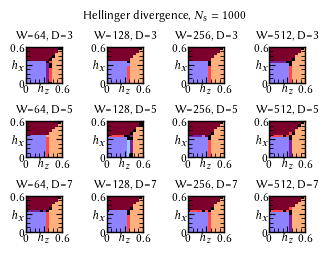

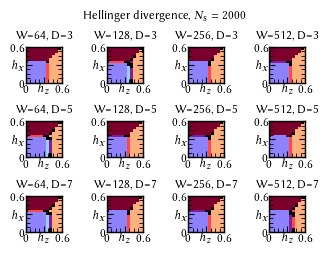

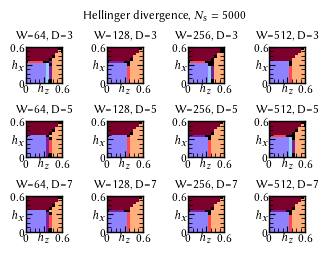

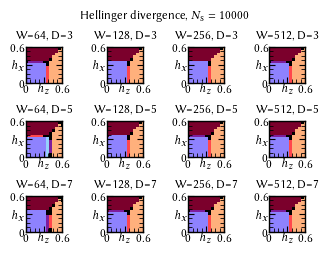

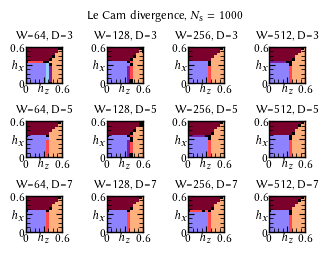

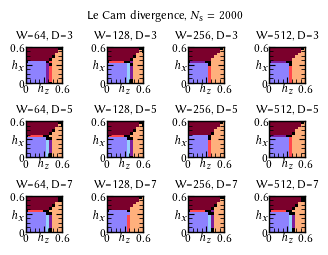

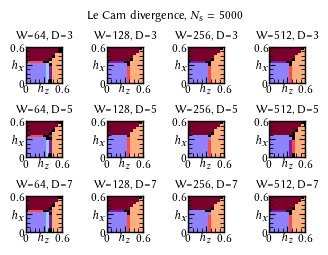

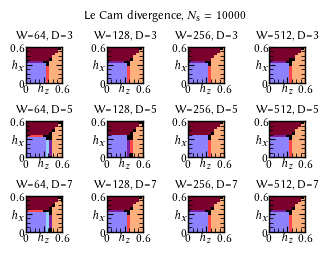

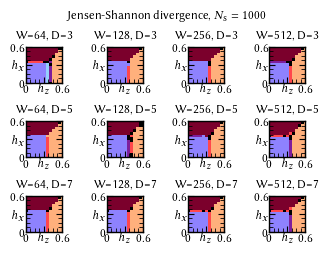

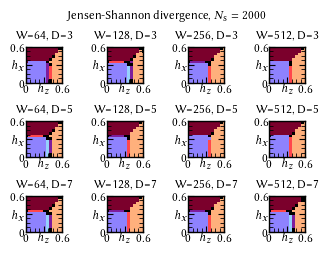

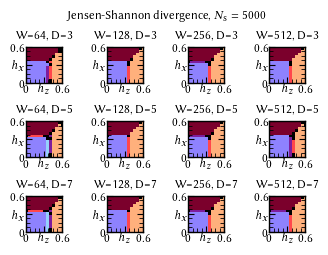

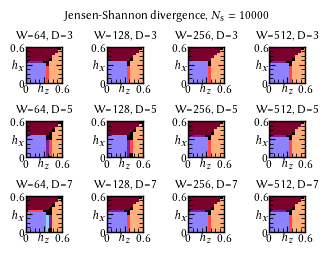

In [13]:
fig_width_cm = 8.25
fig_height_cm = 6
cm2inches = 1 / 2.54

ax_size = (fig_width_cm / num_widths) * cm2inches
for divergence in ('hellinger', 'triangular', 'jensen_shannon'):
    for samples_per_point in unq_sample_sizes:
        fig, axes = plt.subplots(num_depths, num_widths, constrained_layout=True)
        fig.set_figwidth(num_widths * ax_size)
        fig.set_figheight(num_depths * ax_size)
        fig.suptitle(
            f'{divergence2label[divergence]} divergence, ' + r'$N_{\rm s}=' + f'{samples_per_point}$',
            fontsize=LABEL_SIZE,
        )

        # Normalize axes container shape for degenerate grids.
        if num_depths == 1 and num_widths == 1:
            axes = np.asarray([[axes]])
        elif num_depths == 1:
            axes = np.asarray([axes])
        elif num_widths == 1:
            axes = np.asarray([[ax] for ax in axes])

        for row_idx, network_depth in enumerate(unq_depths):
            for col_idx, network_width in enumerate(unq_widths):
                for exp_config in f_matrices_dict:
                    if ((exp_config.samples_per_point != samples_per_point)
                        or (exp_config.network_width != network_width)
                        or (exp_config.network_depth != network_depth)):
                        continue
                    cur_ax = axes[row_idx, col_idx]
                    cur_ax.set_title(f'W={network_width}, D={network_depth}', fontsize=LABEL_SIZE)

                    coords = np.asarray(coords_dict[exp_config])

                    f_matrix = f_matrices_dict[exp_config][divergence]
                    copy_f_matrix = f_matrix.clone()
                    copy_f_matrix = pt.sqrt(copy_f_matrix)

                    # HDBSCAN clustering
                    hdbscan_model = HDBSCAN(metric='precomputed', copy=True)
                    cluster_labels = hdbscan_model.fit_predict(copy_f_matrix)

                    for anchor in anchor2lambda:
                        sorted_coords = sorted(enumerate(coords), key=anchor2lambda[anchor])
                        anchor_idx = sorted_coords[0][0]

                        cur_anchor_label = cluster_labels[anchor_idx]
                        cur_anchor_cluster_mask = (cluster_labels == cur_anchor_label)

                        anchor_conflict_mask = (cluster_labels == anchor2label[anchor])
                        cluster_labels[anchor_conflict_mask] = cur_anchor_label
                        cluster_labels[cur_anchor_cluster_mask] = anchor2label[anchor]

                    x_fields = coords[:, 0]
                    z_fields = coords[:, 1]

                    X, Y = x_fields, z_fields
                    L = cluster_labels
                    xi = np.linspace(X.min(), X.max(), 200)
                    yi = np.linspace(Y.min(), Y.max(), 200)
                    Xi, Yi = np.meshgrid(xi, yi)

                    Li = griddata((X, Y), L, (Xi, Yi), method='nearest')

                    cur_ax.matshow(Li.T,
                                  origin='lower',
                                  extent=[Y.min(), Y.max(), X.min(), X.max()],
                                  cmap=cluster_cmap,
                                  norm=cluster_norm,
                                  interpolation='nearest',
                                  aspect=1 / ((X.max() - X.min()) / (Y.max() - Y.min())))
                    compact_axes(cur_ax, x_tex=r'$h_z$', y_tex=r'$h_x$', bottom_only=True)

                    # Keep original behavior: save inside the innermost loop.
                    fig.savefig(f'./sm_figures/sm_figure_{divergence2idx[divergence] + 2}_{samples_per_point}.pdf',
                                bbox_inches='tight',
                                pad_inches=0.00)
